# Baseline Transfer Learning Model for Error Classification

This notebook implements a baseline Computer Vision model using transfer learning to classify different types of application errors.

## 1. Import Libraries

In [2]:
# Ensure required packages are installed in the active notebook environment.
import importlib
import subprocess
import sys


def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"OK: {package_name} already installed")
    except ModuleNotFoundError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


ensure_package("torch")
ensure_package("torchvision")
ensure_package("scikit-learn", "sklearn")
ensure_package("seaborn")

OK: torch already installed
OK: torchvision already installed
OK: scikit-learn already installed
OK: seaborn already installed


In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0+cpu
Device: cpu


## 2. Data Exploration

In [4]:
# Define data path
data_dir = r"C:\Users\ibf\Desktop\TFM\Nou projecte\Data"

# Get all error categories
error_categories = os.listdir(data_dir)
error_categories = [cat for cat in error_categories if os.path.isdir(os.path.join(data_dir, cat))]
error_categories.sort()

print(f"Error Categories: {error_categories}")
print(f"Number of categories: {len(error_categories)}")

Error Categories: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Number of categories: 8


In [5]:
# Count images per category
image_counts = {}
image_extensions = ('.png', '.jpg', '.jpeg')

for category in error_categories:
    cat_path = os.path.join(data_dir, category)
    images = [f for f in os.listdir(cat_path) 
              if f.lower().endswith(image_extensions)]
    image_counts[category] = len(images)
    print(f"{category}: {len(images)} images")

total_images = sum(image_counts.values())
print(f"\nTotal images: {total_images}")

Banner aplicación: 87 images
Cierre aplicación: 126 images
Error aplicativo: 143 images
Error funcional: 96 images
Error terminal: 377 images
Indeterminado: 99 images
Revisión circuito: 783 images
Timeout: 132 images

Total images: 1843


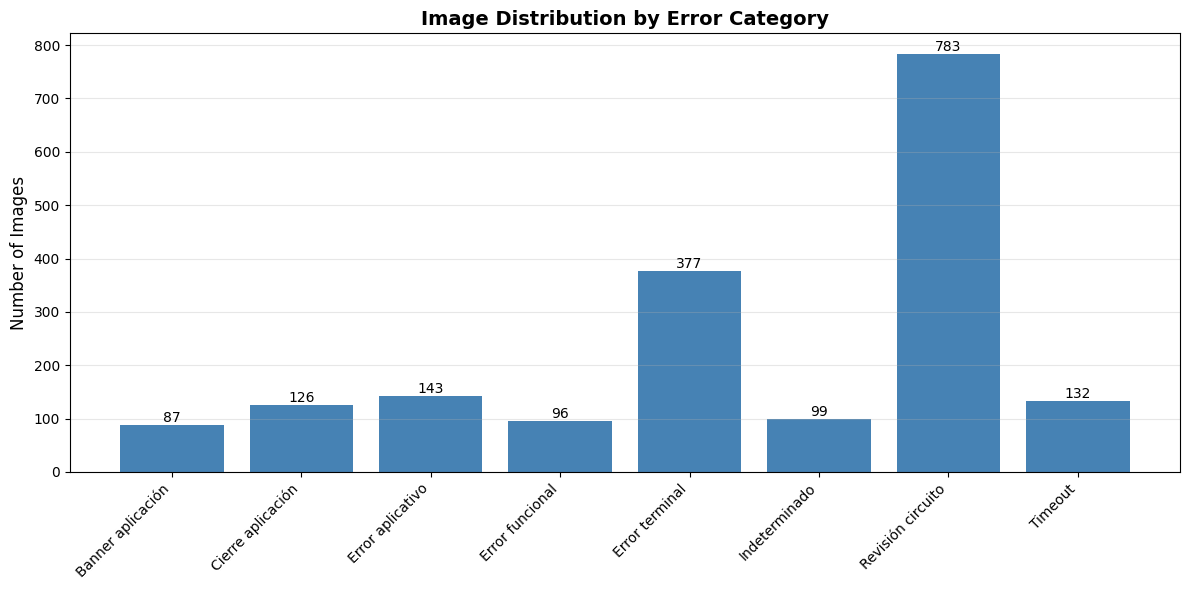


Data Summary:
            Category  Image Count Percentage
0  Banner aplicación           87       4.7%
1  Cierre aplicación          126       6.8%
2   Error aplicativo          143       7.8%
3    Error funcional           96       5.2%
4     Error terminal          377      20.5%
5      Indeterminado           99       5.4%
6  Revisión circuito          783      42.5%
7            Timeout          132       7.2%


In [6]:
# Visualize data distribution
fig, ax = plt.subplots(figsize=(12, 6))
categories = list(image_counts.keys())
counts = list(image_counts.values())

bars = ax.bar(range(len(categories)), counts, color='steelblue')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Distribution by Error Category', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Create summary dataframe
summary_df = pd.DataFrame({
    'Category': categories,
    'Image Count': counts,
    'Percentage': [f"{100*count/total_images:.1f}%" for count in counts]
})
print("\nData Summary:")
print(summary_df)

## 3. Data Preparation

In [7]:
# Define hyperparameters
IMAGE_SIZE = (224, 224)  # Standard size for transfer learning models
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
NUM_WORKERS = 0

print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Validation Split: {VALIDATION_SPLIT}")

Image Size: (224, 224)
Batch Size: 32
Validation Split: 0.2


In [8]:
# Build train/validation datasets with ImageFolder + stratified split
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset_no_tf = datasets.ImageFolder(root=data_dir)
class_names = full_dataset_no_tf.classes
num_classes = len(class_names)

labels = np.array(full_dataset_no_tf.targets)
indices = np.arange(len(full_dataset_no_tf))

train_indices, val_indices = train_test_split(
    indices,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=labels,
)

train_dataset_base = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset_base = datasets.ImageFolder(root=data_dir, transform=val_transform)

train_dataset = Subset(train_dataset_base, train_indices)
val_dataset = Subset(val_dataset_base, val_indices)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Number of classes: 8
Class names: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Training samples: 1474
Validation samples: 369


In [9]:
# Build dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 47
Validation batches: 12


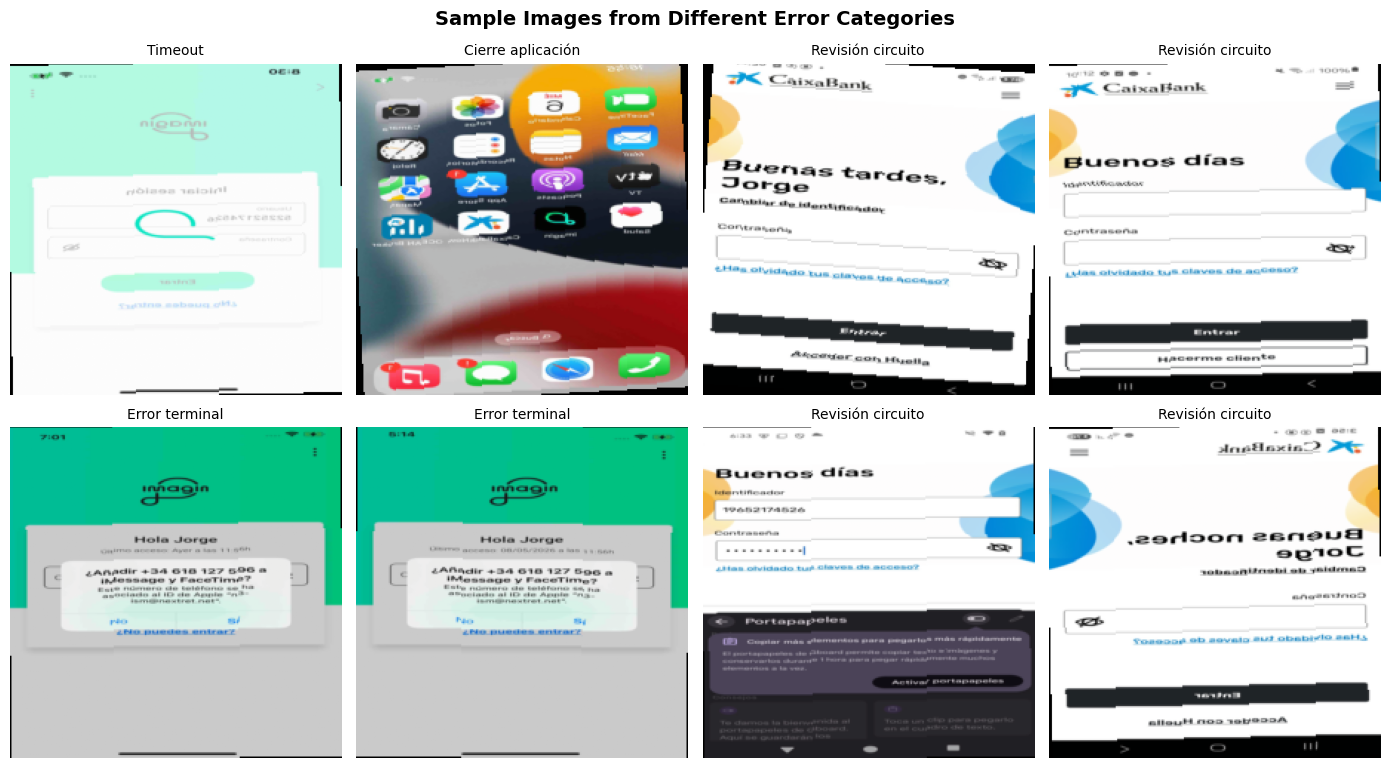

In [10]:
# Visualize sample images
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

images, labels = next(iter(train_loader))
for idx in range(min(8, len(images))):
    ax = axes[idx]
    img = inv_normalize(images[idx]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[int(labels[idx])], fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Images from Different Error Categories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Build Transfer Learning Model

In [11]:
# Load pre-trained EfficientNetB0 model
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# Freeze backbone layers for transfer learning
for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, num_classes),
)

model = model.to(device)

print("Base model: EfficientNetB0 (torchvision)")
print(f"Total model parameters: {sum(p.numel() for p in model.parameters()):,}")

Base model: EfficientNetB0 (torchvision)
Total model parameters: 4,337,540


In [12]:
# Model summary helpers
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(model)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Model Architecture:
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2

In [13]:
# Configure loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
)

print("Loss and optimizer configured.")

Loss and optimizer configured.


## 5. Train Model

In [14]:
# Training controls (PyTorch replacement for callbacks)
EPOCHS = 20
PATIENCE = 5
LR_FACTOR = 0.5
LR_PATIENCE = 3
MIN_LR = 1e-7

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR,
)

print("Training controls configured.")

Training controls configured.


In [15]:
# Train the model with early stopping
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"loss: {train_loss:.4f} | acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best model weights.")

Epoch 1/20 | loss: 0.8880 | acc: 0.7252 | val_loss: 0.3396 | val_acc: 0.9160
Epoch 2/20 | loss: 0.3420 | acc: 0.8928 | val_loss: 0.1838 | val_acc: 0.9539
Epoch 3/20 | loss: 0.2500 | acc: 0.9199 | val_loss: 0.1469 | val_acc: 0.9621
Epoch 4/20 | loss: 0.2219 | acc: 0.9247 | val_loss: 0.1438 | val_acc: 0.9593
Epoch 5/20 | loss: 0.2124 | acc: 0.9240 | val_loss: 0.1277 | val_acc: 0.9593
Epoch 6/20 | loss: 0.1877 | acc: 0.9288 | val_loss: 0.1040 | val_acc: 0.9621
Epoch 7/20 | loss: 0.2209 | acc: 0.9247 | val_loss: 0.1009 | val_acc: 0.9648
Epoch 8/20 | loss: 0.1703 | acc: 0.9349 | val_loss: 0.1048 | val_acc: 0.9621
Epoch 9/20 | loss: 0.1793 | acc: 0.9233 | val_loss: 0.1337 | val_acc: 0.9648
Epoch 10/20 | loss: 0.1528 | acc: 0.9396 | val_loss: 0.0860 | val_acc: 0.9621
Epoch 11/20 | loss: 0.1827 | acc: 0.9355 | val_loss: 0.0946 | val_acc: 0.9621
Epoch 12/20 | loss: 0.1432 | acc: 0.9437 | val_loss: 0.0888 | val_acc: 0.9621
Epoch 13/20 | loss: 0.1281 | acc: 0.9437 | val_loss: 0.0885 | val_acc: 0.

AttributeError: 'dict' object has no attribute 'history'

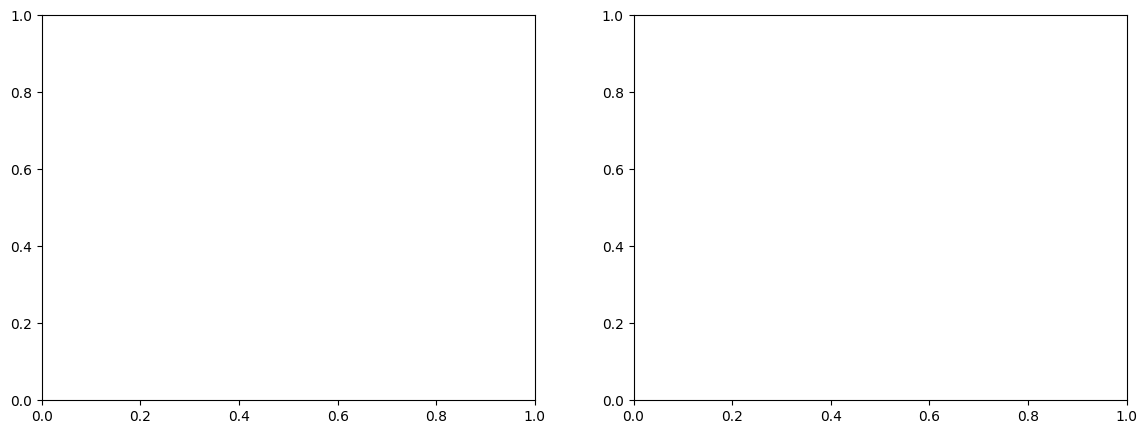

In [16]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"Total epochs: {len(history.history['loss'])}")
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best val loss: {min(history.history['val_loss']):.4f}")

## 6. Model Evaluation

In [17]:
# Evaluate on validation set
val_loss = history["val_loss"][-1]
val_accuracy = history["val_accuracy"][-1]

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 0.0833
Validation Accuracy: 0.9648


In [18]:
# Get predictions for confusion matrix and classification report
y_pred = []
y_true = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Validation Accuracy (sklearn): {accuracy_score(y_true, y_pred):.4f}")

Predictions shape: (369,)
True labels shape: (369,)
Validation Accuracy (sklearn): 0.9621


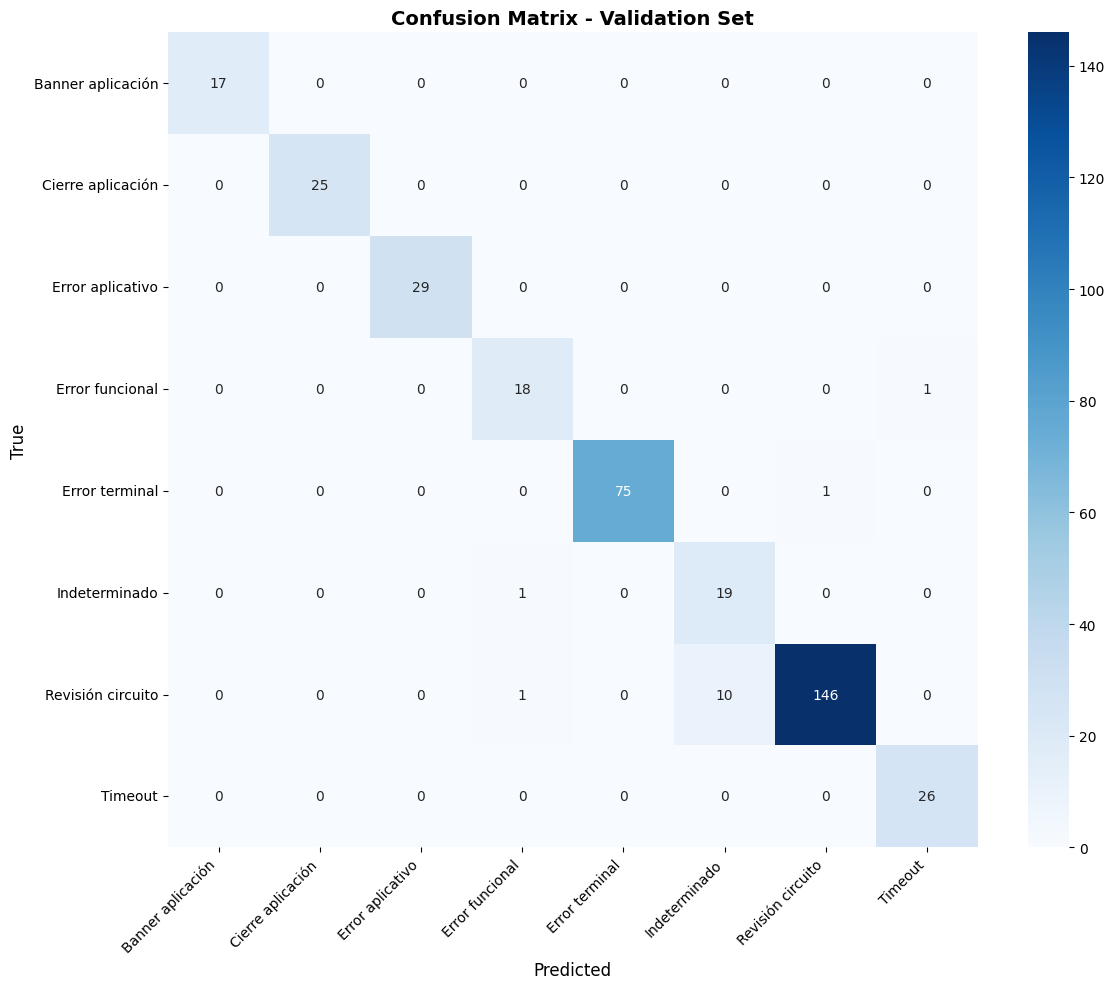

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        17
Cierre aplicación       1.00      1.00      1.00        25
 Error aplicativo       1.00      1.00      1.00        29
  Error funcional       0.90      0.95      0.92        19
   Error terminal       1.00      0.99      0.99        76
    Indeterminado       0.66      0.95      0.78        20
Revisión circuito       0.99      0.93      0.96       157
          Timeout       0.96      1.00      0.98        26

         accuracy                           0.96       369
        macro avg       0.94      0.98      0.95       369
     weighted avg       0.97      0.96      0.96       369



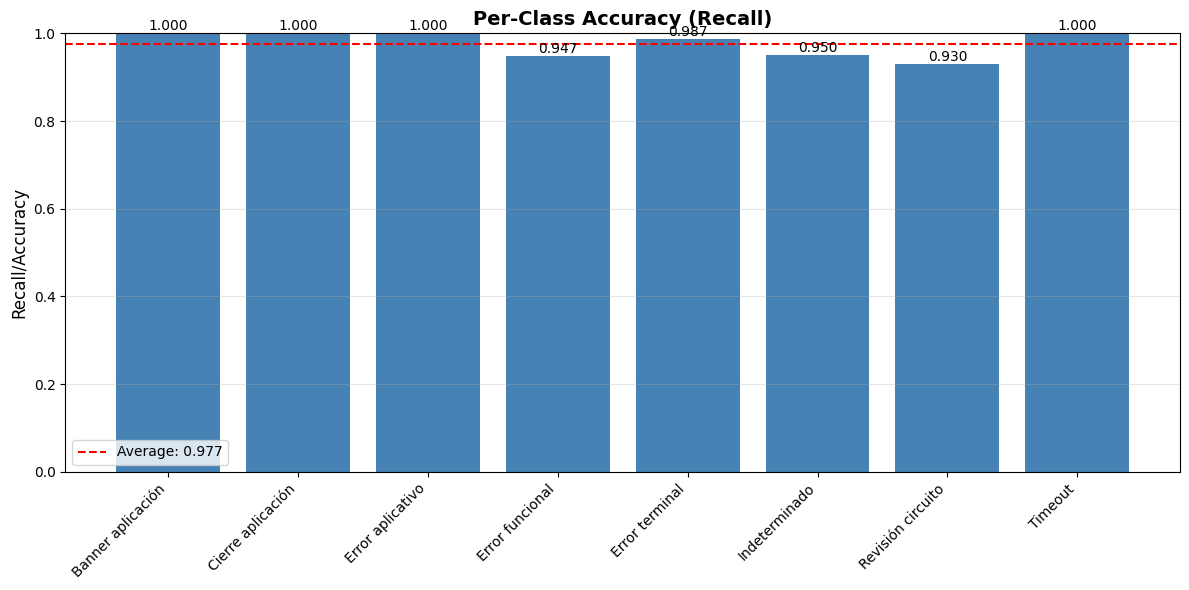

In [21]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(class_names)), per_class_acc, color='steelblue')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('Recall/Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy (Recall)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=np.mean(per_class_acc), color='r', linestyle='--', label=f'Average: {np.mean(per_class_acc):.3f}')
ax.legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 7. Save Model

In [22]:
# Create Models directory if it doesn't exist
models_dir = r"C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models"
os.makedirs(models_dir, exist_ok=True)

# Save model weights and metadata
model_path = os.path.join(models_dir, "baseline_model_efficientnetb0.pth")
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "image_size": IMAGE_SIZE,
    },
    model_path,
)
print(f"Model saved to: {model_path}")

# Save class names
class_names_path = os.path.join(models_dir, "class_names.json")
with open(class_names_path, "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
print(f"Class names saved to: {class_names_path}")

Model saved to: C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models\baseline_model_efficientnetb0.pth
Class names saved to: C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models\class_names.json


## 8. Model Summary and Key Insights

In [23]:
# Summary statistics
summary_stats = {
    "Total Images": total_images,
    "Number of Classes": num_classes,
    "Training Samples": len(train_dataset),
    "Validation Samples": len(val_dataset),
    "Image Size": str(IMAGE_SIZE),
    "Base Model": "EfficientNetB0 (torchvision)",
    "Total Parameters": sum(p.numel() for p in model.parameters()),
    "Trainable Parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "Epochs Trained": len(history["loss"]),
    "Final Train Accuracy": f"{history['accuracy'][-1]:.4f}",
    "Final Val Accuracy": f"{history['val_accuracy'][-1]:.4f}",
    "Best Val Accuracy": f"{max(history['val_accuracy']):.4f}",
    "Final Train Loss": f"{history['loss'][-1]:.4f}",
    "Final Val Loss": f"{history['val_loss'][-1]:.4f}",
}

print("\n" + "=" * 50)
print("BASELINE MODEL SUMMARY")
print("=" * 50)
for key, value in summary_stats.items():
    print(f"{key:.<30} {value}")
print("=" * 50)


BASELINE MODEL SUMMARY
Total Images.................. 1843
Number of Classes............. 8
Training Samples.............. 1474
Validation Samples............ 369
Image Size.................... (224, 224)
Base Model.................... EfficientNetB0 (torchvision)
Total Parameters.............. 4337540
Trainable Parameters.......... 329992
Epochs Trained................ 20
Final Train Accuracy.......... 0.9525
Final Val Accuracy............ 0.9648
Best Val Accuracy............. 0.9648
Final Train Loss.............. 0.0966
Final Val Loss................ 0.0833


In [24]:
# Create a summary report
report_df = pd.DataFrame({
    'Error Category': class_names,
    'Train Samples': [image_counts[cat] for cat in class_names],
    'Recall': [f"{per_class_acc[i]:.4f}" for i in range(len(class_names))],
    'Support': cm.sum(axis=1)
})

print("\nPer-Class Performance:")
print(report_df.to_string(index=False))


Per-Class Performance:
   Error Category  Train Samples Recall  Support
Banner aplicación             87 1.0000       17
Cierre aplicación            126 1.0000       25
 Error aplicativo            143 1.0000       29
  Error funcional             96 0.9474       19
   Error terminal            377 0.9868       76
    Indeterminado             99 0.9500       20
Revisión circuito            783 0.9299      157
          Timeout            132 1.0000       26
